In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('train.csv')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:

print(f"Dataset shape: {df.shape}")

df.info()

Dataset shape: (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-nu

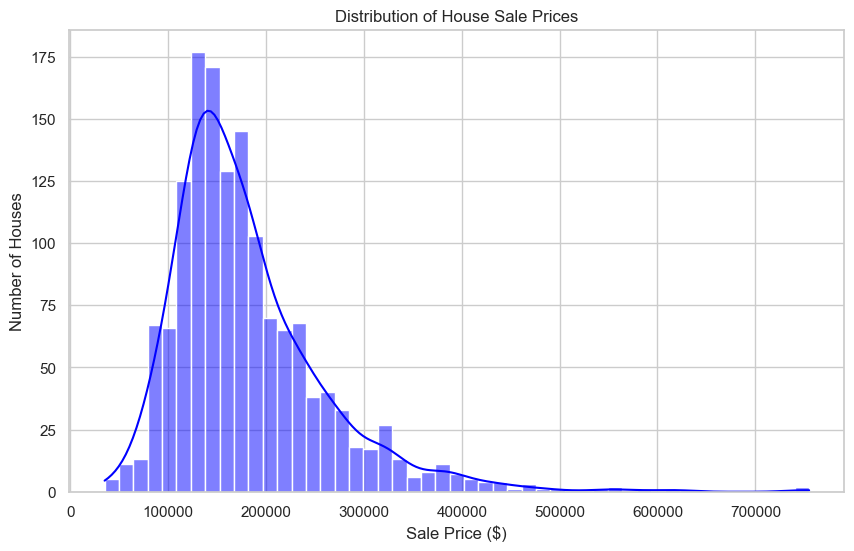

In [7]:

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, color='blue')
plt.title('Distribution of House Sale Prices')
plt.xlabel('Sale Price ($)')
plt.ylabel('Number of Houses')
plt.show()

In [8]:

numeric_data = df.select_dtypes(include=['int64', 'float64'])

correlations = numeric_data.corr()['SalePrice'].sort_values(ascending=False)


print("Top 10 features that drive House Prices up:")
print(correlations.head(11))

Top 10 features that drive House Prices up:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [9]:

features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']


X = df[features].copy()
y = df['SalePrice']


X = X.fillna(X.median())

print("Data successfully preprocessed!")
print(f"X (Features) shape: {X.shape}")
print(f"y (Target) shape: {y.shape}")

Data successfully preprocessed!
X (Features) shape: (1460, 6)
y (Target) shape: (1460,)


In [11]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} houses")
print(f"Testing data size: {X_test.shape[0]} houses")

Training data size: 1168 houses
Testing data size: 292 houses


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


model = RandomForestRegressor(random_state=42)

print("Training the AI... this might take a few seconds...")
model.fit(X_train, y_train)


predictions = model.predict(X_test)


error = mean_absolute_error(y_test, predictions)

print("Model Training Complete!")
print(f"On average, our AI's price predictions are off by: ${error:,.2f}")

Training the AI... this might take a few seconds...
Model Training Complete!
On average, our AI's price predictions are off by: $19,210.50


In [14]:
import joblib

# Export the trained model to a file in your folder
joblib.dump(model, 'house_model.pkl')

print("Model successfully saved as house_model.pkl!")

Model successfully saved as house_model.pkl!
